In [1]:
import pandas as pd
import numpy as np
import ast

In [2]:
credits = pd.read_csv('tmdb_5000_credits.csv')
movies = pd.read_csv('tmdb_5000_movies.csv')

In [3]:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4803 non-null   int64 
 1   title     4803 non-null   object
 2   cast      4803 non-null   object
 3   crew      4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB


In [4]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [5]:
print(movies.columns)

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')


In [6]:
credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [7]:
movies = movies.merge(credits, left_on='title', right_on='title')

In [8]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [9]:
movies = movies[['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew']]


In [10]:
movies.head(1)

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [11]:
def convert(obj):
    L = []
    for i in ast.literal_eval(obj):
        L.append(i['name'])
    return L

In [12]:
movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)

In [13]:
movies['cast'] = movies['cast'].apply(
    lambda x: [i['name'] for i in ast.literal_eval(x)[:3]]
)

In [14]:
movies['crew'] = movies['crew'].apply(
    lambda x: [i['name'] for i in ast.literal_eval(x) if i['job'] == 'Director']
)

In [15]:
movies['tags'] = movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']
movies['tags'] = movies['tags'].apply(lambda x: " ".join(x))

In [16]:
movies = movies[['movie_id', 'title', 'overview', 'tags']]
movies['tags'] = movies['tags'].apply(lambda x: x.lower())

movies.head()

,movie_id,title,overview,tags
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...",action adventure fantasy science fiction cultu...
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",adventure fantasy action ocean drug abuse exot...
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,action adventure crime spy based on novel secr...
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,action crime drama thriller dc comics crime fi...
4,49529,John Carter,"John Carter is a war-weary, former military ca...",action adventure science fiction based on nove...


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['tags'])

In [18]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [19]:
def get_recommendations(title, cosine_sim=cosine_sim):
    idx = movies[movies['title'] == title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11] 
    movie_indices = [i[0] for i in sim_scores]
    return movies['title'].iloc[movie_indices]

In [20]:
print(get_recommendations('The Dark Knight Rises'))

65               The Dark Knight
119                Batman Begins
1360                      Batman
210               Batman & Robin
428               Batman Returns
1361                      Batman
1197                The Prestige
303                     Catwoman
4644    Amidst the Devil's Wings
72                 Suicide Squad
Name: title, dtype: object


In [21]:
import pickle

with open('movie_data.pkl', 'wb') as file:
    pickle.dump((movies, cosine_sim), file)

In [22]:
def evaluate_recommendations(title, top_k=10):
    recs = get_recommendations(title)[:top_k]
    input_genres = set(movies[movies['title']==title]['tags'].iloc[0].split())
    match_count = 0
    for rec in recs:
        rec_genres = set(movies[movies['title']==rec]['tags'].iloc[0].split())
        if len(input_genres & rec_genres) > 0:
            match_count += 1
    
    print(f"Title: {title}")
    print(f"Recommended Movies: {list(recs)}")
    print(f"Number of genre matches: {match_count}/{top_k}")
    print(f"Genre match ratio: {match_count/top_k:.2f}")

evaluate_recommendations('The Dark Knight Rises')

Title: The Dark Knight Rises
Recommended Movies: ['The Dark Knight', 'Batman Begins', 'Batman', 'Batman & Robin', 'Batman Returns', 'Batman', 'The Prestige', 'Catwoman', "Amidst the Devil's Wings", 'Suicide Squad']
Number of genre matches: 10/10
Genre match ratio: 1.00


In [23]:
def get_recommendations(title, top_k=10, cosine_sim=cosine_sim):
    """
    Returns a DataFrame of recommended movies (top_k) including 'tags' column
    """
    idx = movies[movies['title'] == title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_k+1]  # top_k similar movies
    movie_indices = [i[0] for i in sim_scores]
    return movies.iloc[movie_indices]

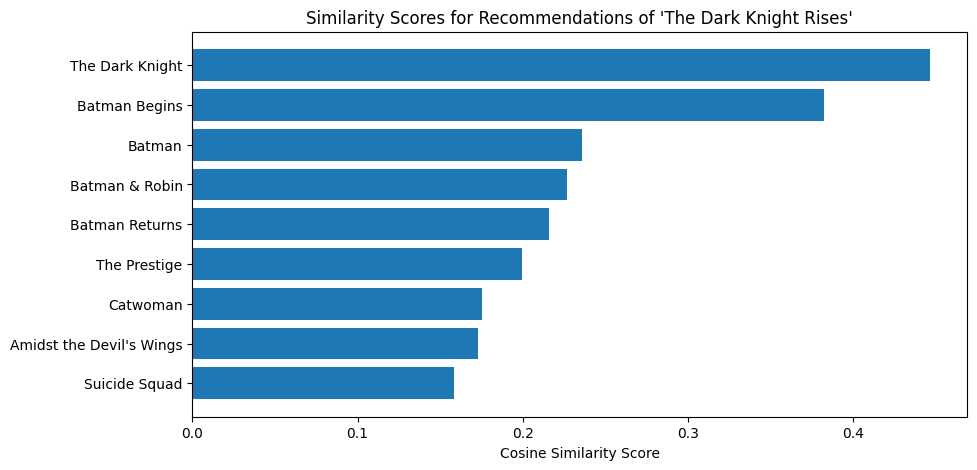

In [ ]:
import matplotlib.pyplot as plt

def plot_similarity_scores(title, top_k=10):
    idx = movies[movies['title'] == title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_k+1]

    movie_indices = [i[0] for i in sim_scores]
    movie_titles = movies.iloc[movie_indices]['title']
    scores = [s[1] for s in sim_scores]

    plt.figure(figsize=(10, 5))
    plt.barh(movie_titles, scores)
    plt.xlabel("Cosine Similarity Score")
    plt.title(f"Similarity Scores for Recommendations of '{title}'")
    plt.gca().invert_yaxis()
    plt.show()

plot_similarity_scores('The Dark Knight Rises')

In [ ]:
def get_recommendations(title, cosine_sim=cosine_sim):
    idx = movies.index[movies['title'] == title][0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:11]

    movie_indices = [i[0] for i in sim_scores]
    return movies.iloc[movie_indices]['title'].tolist()

print(get_recommendations("The Dark Knight Rises"))

['The Dark Knight', 'Batman Begins', 'Batman', 'Batman & Robin', 'Batman Returns', 'Batman', 'The Prestige', 'Catwoman', "Amidst the Devil's Wings", 'Suicide Squad']


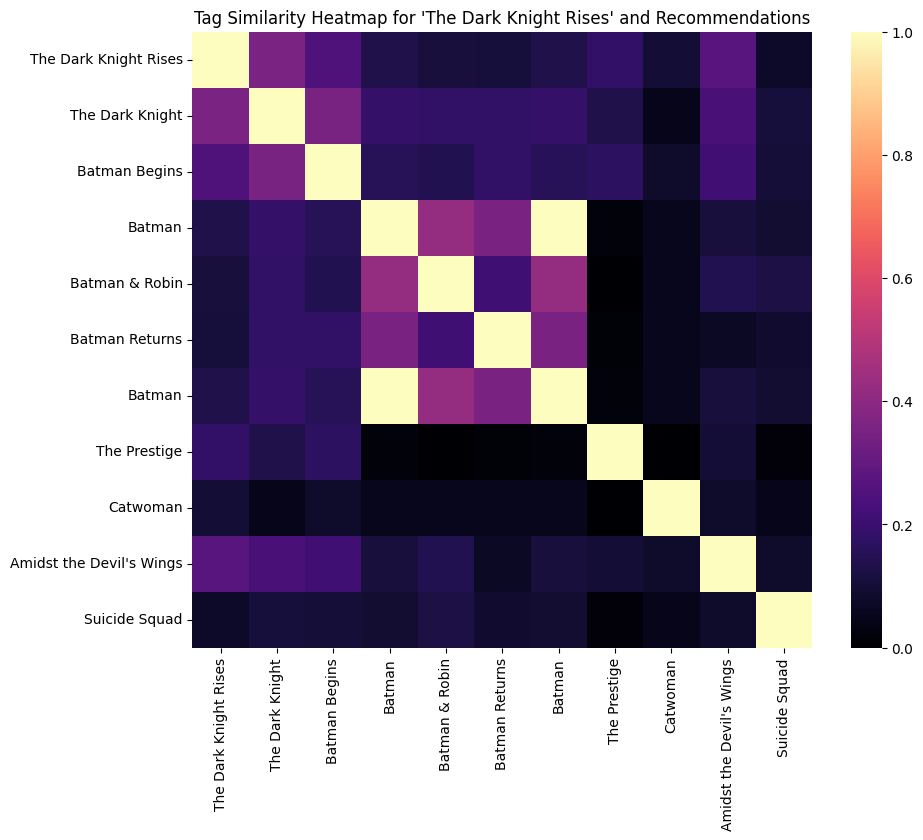

In [ ]:
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def plot_tag_overlap(title, top_k=10):
    if title not in set(movies['title']):
        raise ValueError(f"Title '{title}' not found in movies dataset.")
    
    recs = list(get_recommendations(title)[:top_k])
    titles = [title] + recs
    tag_list = []

    for t in titles:
        tags_series = movies.loc[movies['title'] == t, 'tags']
        if tags_series.empty:
            tag_list.append("")
        else:
            tag_list.append(tags_series.iloc[0])
    
    vectorizer = TfidfVectorizer(stop_words='english')
    tag_matrix = vectorizer.fit_transform(tag_list)

    sim = cosine_similarity(tag_matrix)

    plt.figure(figsize=(10, 8))
    sns.heatmap(sim, xticklabels=titles, yticklabels=titles, cmap="magma", annot=False)
    plt.title(f"Tag Similarity Heatmap for '{title}' and Recommendations")
    plt.show()

plot_tag_overlap('The Dark Knight Rises')

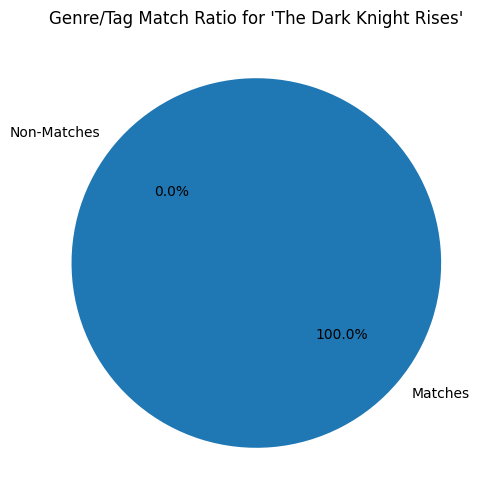

In [28]:
def plot_genre_match(title, top_k=10):
    recs = list(get_recommendations(title)[:top_k])
    input_tags = set(movies[movies['title']==title]['tags'].iloc[0].split())

    matches = 0
    for rec in recs:
        rec_tags = set(movies[movies['title']==rec]['tags'].iloc[0].split())
        if input_tags & rec_tags:
            matches += 1

    non_matches = top_k - matches

    plt.figure(figsize=(6, 6))
    plt.pie([matches, non_matches],
            labels=["Matches", "Non-Matches"],
            autopct='%1.1f%%',
            startangle=140)
    plt.title(f"Genre/Tag Match Ratio for '{title}'")
    plt.show()

plot_genre_match('The Dark Knight Rises')